## Loading Necessary Dependencies

Let's import the libraries that we are going to use for data manipulation, visualization, training the model, etc.
We are going to train the LSTM using PyTorch library.

In [0]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 

##### IF you use light theme ,dont run this 
plt.rcParams[
    "figure.facecolor"
] = "w"  # force white background on plots when using dark mode in JupyterLab

 ## Load data


##### (a) the real data for Germany or Berlin

In [0]:
## USE RKI Cases and death  report

# read the data
deadth_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/deaths-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)
case_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/cases-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)

##### (b) from one of your SIR scenarios

In [0]:
df_B = pd.read_csv('data_B.csv')
df_B = df_B.iloc[:,1:]

##### (c) from one of your agent-based scenarios

In [0]:
df_C = pd.read_csv('data_C.csv')
df_C = df_C[df_C['Metric'] == "Infected" ]

df_C[["Avg", "Max"]]= df_C[["Avg", "Max"]].multiply(200) # multiply by population 

In [0]:
df_C[["Avg", "Max"]] = df_C[["Avg", "Max"]].astype(int)

## Prepare Training /Testing set

(a)
 For the real data, use data for 01.03.2020-20.04.2020 for training and then predict 21.4.-30.04.2020.

In [0]:
df_A_Train = case_RKI_report.loc['2020-03-01':'2020-04-20']
df_A_Test = case_RKI_report.loc['2020-04-21':'2020-04-30']

In [0]:
df_A_Train.columns

Index(['DE-SH', 'DE-HH', 'DE-NI', 'DE-HB', 'DE-NW', 'DE-HE', 'DE-RP', 'DE-BW',
       'DE-BY', 'DE-SL', 'DE-BB', 'DE-MV', 'DE-SN', 'DE-ST', 'DE-TH', 'DE-BE',
       'sum_cases'],
      dtype='object')

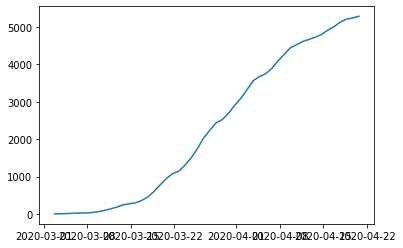

In [0]:
plt.plot(df_A_Train["DE-BE"])

(b)
From SEIR model

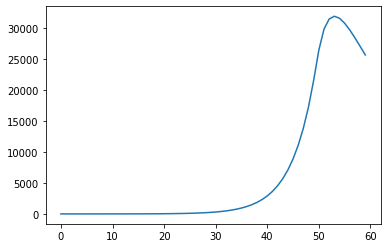

In [0]:
plt.plot(df_B["Infected  Cases"])

(c) 
From Agent Based - use avg number or max

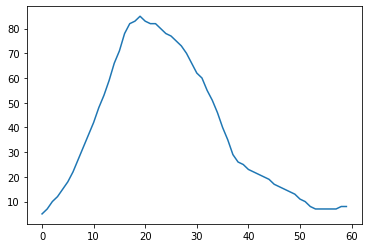

In [0]:
plt.plot(df_C["Iteration"][:60], df_C["Avg"][:60])

In [0]:
df_C.dropna()
df_C=df_C["Avg"].reset_index()

## Fitting 

##### (a)

In [0]:
import pandas as pd
from fbprophet import Prophet
from fbprophet.plot import add_changepoints_to_plot
from fbprophet.diagnostics import cross_validation
from fbprophet.diagnostics import performance_metrics
from fbprophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

In [0]:
df_final = pd.DataFrame()
df_final['ds'] = pd.to_datetime(df_A_Train.index)
df_final['y'] = df_A_Train['DE-BE'].values

In [0]:
df_final['ds']  =df_final['ds'] .dt.tz_localize(None) #remove timezone from a Timestamp column 
df_final['ds']

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


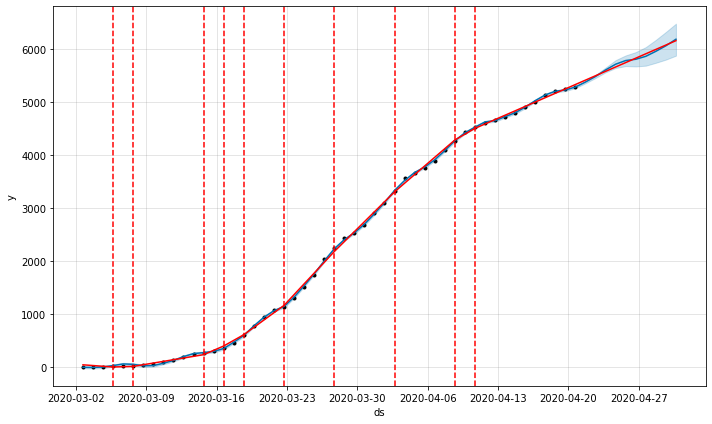

In [0]:
prophet = Prophet()
prophet.add_country_holidays(country_name='DE')
prophet.fit(df_final)
future = prophet.make_future_dataframe(periods=10, freq='D') # <-- Use day , and predict ten days ahead 
forecast = prophet.predict(future)
fig = prophet.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), prophet, forecast)

In [0]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print('Train Mean Absolute Error:', mean_absolute_error(df_A_Train['DE-BE'].values, forecast.iloc[0:50,-1]))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(df_A_Train['DE-BE'].values, forecast.iloc[0:50,-1])))
print('Test Mean Absolute Error:', mean_absolute_error(df_A_Test['DE-BE'].values, forecast.iloc[50:60,-1].values))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(df_A_Test['DE-BE'].values, forecast.iloc[50:60,-1].values)))

Train Mean Absolute Error: 12.538449351885307
Train Root Mean Squared Error: 16.28679838772258
Test Mean Absolute Error: 124.36050454246579
Test Root Mean Squared Error: 139.91172325754854


In [0]:
A_pred = forecast[50:]
A_pred = A_pred.iloc[:,1]

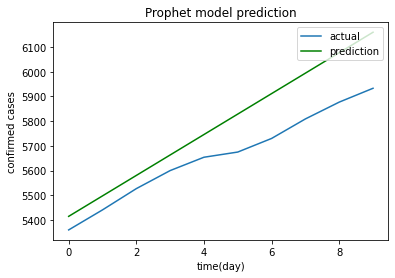

In [0]:
plt.plot(df_A_Test['DE-BE'].values, label="actual")
plt.plot(A_pred.values, label="prediction", color='green')

plt.title('Prophet model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

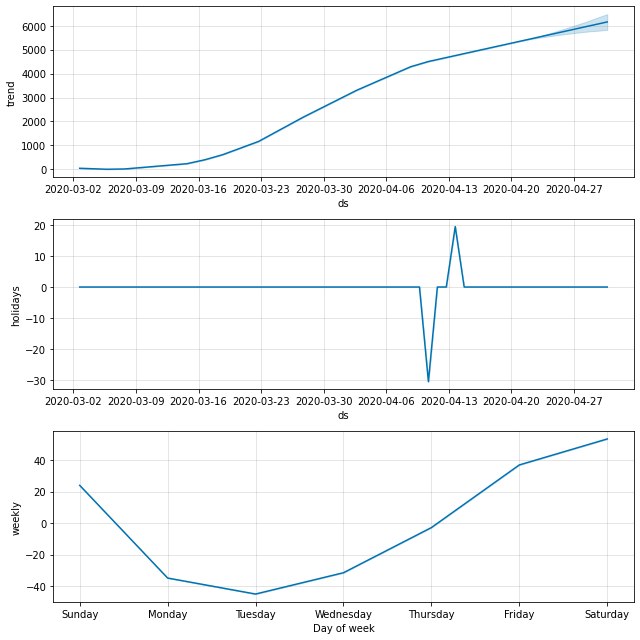

In [0]:
fig = prophet.plot_components(forecast)

In [0]:
fig.gca()

##### (b)


In [0]:
df_sir = pd.DataFrame()
df_sir['y']= df_B["Infected  Cases"][:50].values
df_sir['ds']= df_final['ds']

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


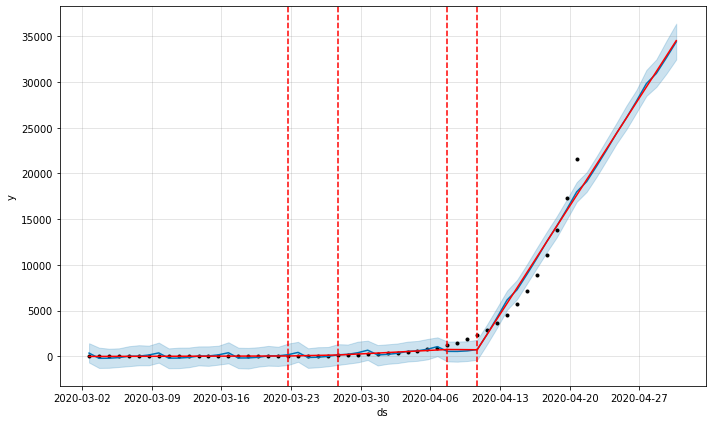

In [0]:
prophet_b = Prophet(changepoint_prior_scale=0.9)
prophet_b.fit(df_sir)
future_b = prophet_b.make_future_dataframe(periods=10, freq='D') # <-- Use day , and predict ten days ahead 
forecast_b = prophet_b.predict(future_b)
fig_b = prophet_b.plot(forecast_b)
a = add_changepoints_to_plot(fig_b.gca(), prophet_b, forecast_b)

In [0]:
print('Train Mean Absolute Error:', mean_absolute_error(df_B["Infected  Cases"][:50].values, forecast_b.iloc[0:50,-1]))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(df_B["Infected  Cases"][:50].values, forecast_b.iloc[0:50,-1])))
print('Test Mean Absolute Error:', mean_absolute_error(df_B["Infected  Cases"][50:60].values, forecast_b.iloc[50:60,-1].values))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(df_B["Infected  Cases"][50:60].values, forecast_b.iloc[50:60,-1].values)))

Train Mean Absolute Error: 490.22208248698144
Train Root Mean Squared Error: 851.8187362507059
Test Mean Absolute Error: 5822.2678203784135
Test Root Mean Squared Error: 6518.30133927852


In [0]:
B_pred = forecast_b[50:]
B_pred = B_pred.iloc[:,1]

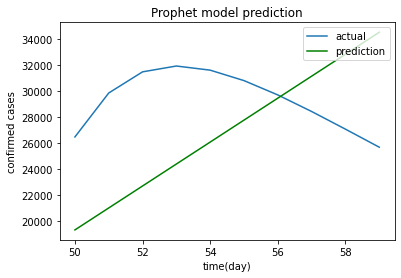

In [0]:
plt.plot(df_B["Infected  Cases"][50:60], label="actual")
plt.plot(B_pred, label="prediction", color='green')

plt.title('Prophet model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

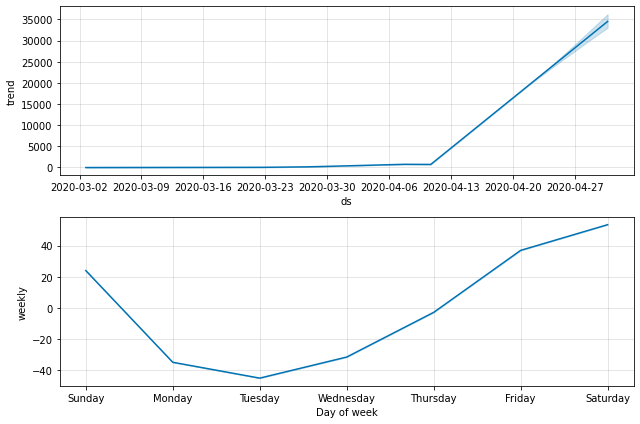

In [0]:
fig = prophet.plot_components(forecast_b)

##### (c)


In [0]:
y =  df_C["Avg"][:50]
ds = df_final['ds']
df_abm = pd.concat([ds, y], axis=1)
df_abm = df_abm.rename(columns={"Avg":"y"})

In [0]:
df_abm

INFO:fbprophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


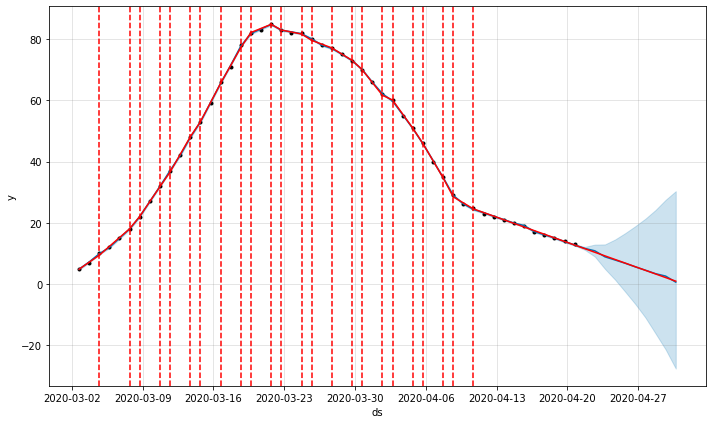

In [0]:
prophet = Prophet(changepoint_prior_scale=0.9)
prophet.fit(df_abm)
future_c = prophet.make_future_dataframe(periods=10, freq='D') # <-- Use day , and predict ten days ahead 
forecast_c = prophet.predict(future_c)
fig = prophet.plot(forecast_c)
a = add_changepoints_to_plot(fig.gca(), prophet, forecast_c)

In [0]:
print('Train Mean Absolute Error:', mean_absolute_error(df_C["Avg"][:50].values, forecast_c.iloc[0:50,-1]))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(df_C["Avg"][:50].values, forecast_c.iloc[0:50,-1])))
print('Test Mean Absolute Error:', mean_absolute_error(df_C["Avg"][50:60].values, forecast_c.iloc[50:60,-1].values))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(df_C["Avg"][50:60].values, forecast_c.iloc[50:60,-1].values)))

Train Mean Absolute Error: 0.15309368297178763
Train Root Mean Squared Error: 0.20328204892449744
Test Mean Absolute Error: 2.367690393019454
Test Root Mean Squared Error: 3.2710616667253722


In [0]:
C_pred = forecast_c[50:]
C_pred = C_pred.iloc[:,1]

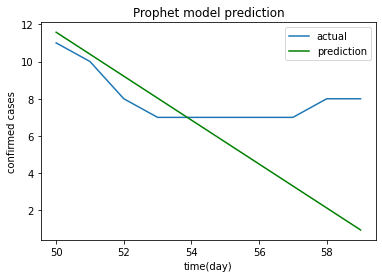

In [0]:
plt.plot(df_C["Avg"][50:60], label="actual")
plt.plot(C_pred, label="prediction", color='green')

plt.title('Prophet model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

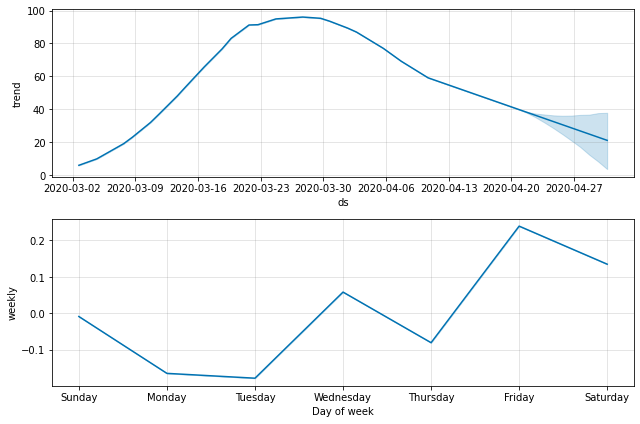

In [0]:
fig = prophet.plot_components(forecast_c)